# Градиентный спуск

В данном задании необходимо реализовать метод градиентного спуска (функция gradient_descent) и
процедуру линейного поиска (метод line_search в класce LineSearchTool в модуле optimization).



**Алгоритм 1: Общая схема метода спуска**

**Вход:** Начальная точка $x_0$; максимальное число итераций $K$.

1. **for** $k \leftarrow 0$ **to** $K$ **do**
2. &emsp; **(Вызов оракула)** Вычислить $f(x_k)$, $\nabla f(x_k)$ и пр.
3. &emsp; **(Критерий остановки)** Если выполнен критерий остановки, то выход.
4. &emsp; **(Вычисление направления)** Вычислить направление спуска $d_k$.
5. &emsp; **(Линейный поиск)** Найти подходящую длину шага $\alpha_k$.
6. &emsp; **(Обновление)** $x_{k+1} \leftarrow x_k + \alpha_k d_k$.
7. **end for**

**Выход:** Последняя вычисленная точка $x_k$

In [1]:
import numpy as np
from numpy.linalg import LinAlgError
import scipy
from datetime import datetime
from collections import defaultdict
from scipy.special import expit
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

**Критерий остановки**

Наиболее популярным критерием остановки является критерий, основанный на норме градиента: $\| \nabla f(x_k) \|_2^2 < \tilde{\varepsilon}$.  
Квадрат здесь ставят за тем, что для «хороших» функций невязка по функции $f(x_k) - f^*$ имеет тот же порядок, что $u = \| \nabla f(x_k) \|_2^2$, а не $\| \nabla f(x_k) \|_2^1$; например, если $\| \nabla f(x_k) \|_2 \sim 10^{-5}$, то $f(x_k) - f^* \sim 10^{-10}$.  
Наконец, для того, чтобы критерий не зависел от того, измеряется ли функция $f$ «в метрах» или «в километрах» (т. е. не изменялся при переходе от функции $f$ к функции $tf$, где $t > 0$), то имеет смысл использовать следующий относительный вариант критерия:  

$$\| \nabla f(x_k) \|_2^2 \leq \epsilon \| \nabla f(x_0) \|_2^2$$

где $\epsilon \in (0, 1)$ — заданная относительная точность. Таким образом, данный критерий остановки гарантирует, что метод уменьшит начальную невязку $\| \nabla f(x_0) \|_2$ в $\epsilon^{-1}$ раз. В этом задании Вам нужно будет во всех методах использовать этот критерий остановки.


**Линейный поиск**

Рассматривается функция  
$$\phi_k(\alpha) := f(x_k + \alpha d_k)$$


Заметим, что  
$$\phi_k'(\alpha) = \langle \nabla f(x_k + \alpha d_k), d_k \rangle $$

Поскольку $d_k$ является направлением спуска, то $\phi'(0) = \langle \nabla f(x_k), d_k \rangle < 0$.

Условием Армихо для $\alpha$ называется выполнение следующего неравенства:  
$$\phi_k(\alpha) \leq \phi_k(0) + c_1 \alpha \phi_k'(0)$$

где $c_1 \in (0, 0.5)$ - некоторая константа.

Для поиска точки $\alpha$, удовлетворяющей условию Армихо, обычно используют следующую процедуру - метод дробления шага (бэктрэкинг):


**Алгоритм 2: Метод дробления шага (бэктрэкинг)**

**Вход:** Функция $\phi_k : \mathbb{R}_+ \rightarrow \mathbb{R}$; начальное значение шага $\alpha_k^{(0)}$.

1. $\alpha \leftarrow \alpha_k^{(0)}$
2. **while** $\phi_k(\alpha) > \phi_k(0) + c_1 \alpha \phi_k'(0)$ **do**
3. &emsp; $\alpha \leftarrow \alpha/2$
4. **end while**

**Выход:** $\alpha$

«Адаптивный» метод подбора шага запоминает величину $\alpha_k$, найденную на текущей итерации и на следующей итерации начинает процедуру дробления с $\alpha_{k+1}^{(0)} := 2\alpha_k$. Исключение здесь составляют ньютоновские и квазиньютоновские методы - в этих методах процедуру дробления шага всегда нужно начинать с $\alpha_k^{(0)} := 1$.

Сильные условия Вульфа:
$$\phi_k(\alpha) \leq \phi(0) + c_1 \alpha \phi_k'(0)$$
$$| \phi_k'(\alpha)| \leq c_2 |\phi_k'(0)|
$$

Здесь $c_1 \in (0, 0.5), c_2 \in (c_1, 1)$.


*Рекомендация:* Для поиска точки, удовлетворяющей сильным условиям Вульфа,
воспользуйтесь библиотечной функцией scalar_search_wolfe2 из модуля scipy.optimize.linesearch. В ней начальная длина шага $\alpha_k^{(0)}$ автоматически выбирается равной 1.
Однако следует иметь в виду, что у этой библиотечной функции имеется один недостаток: она иногда не сходится и возвращает значение None.
Если библиотечный метод вернул None, то запустите процедуру дробления шага (бэктрекинг) для поиска точки, удовлетворяющей условию Армихо.
Для методов Brent и golden можно использовать scipy.optimize.minimize_scalar


In [2]:
class LineSearchTool(object):
    """
    Line search tool for adaptively tuning the step size of the algorithm.

    method : String containing 'Wolfe', 'Armijo', 'Constant', 'Brent' anvvvd 'Golden',
        Method of tuning step-size.
        Must be be one of the following strings:
            - 'Wolfe' -- enforce strong Wolfe conditions;
            - 'Armijo" -- adaptive Armijo rule;
            - 'Constant' -- constant step size;
            - 'Brent' -- Brent's method for exact line search;
            - 'Golden' -- golden section search for exact line search..
    kwargs :
        Additional parameters of line_search method:

        If method == 'Wolfe':
            c1, c2 : Constants for strong Wolfe conditions
            alpha_0 : Starting point for the backtracking procedure
                to be used in Armijo method in case of failure of Wolfe method.
        If method == 'Armijo':
            c1 : Constant for Armijo rule
            alpha_0 : Starting point for the backtracking procedure.
        If method == 'Constant':
            c : The step size which is returned on every step.
        If method == 'Brent' or 'Golden':
            bracket : Tuple (a, b) for the initial bracket interval for minimization.
                     If not provided, will be determined automatically.
            tol : Tolerance for termination (optional)
    """
    def __init__(self, method='Wolfe', **kwargs):
        self._method = method
        if self._method == 'Wolfe':
            self.c1 = kwargs.get('c1', 1e-4)
            self.c2 = kwargs.get('c2', 0.9)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Armijo':
            self.c1 = kwargs.get('c1', 1e-4)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Constant':
            self.c = kwargs.get('c', 1.0)
        elif self._method == 'Brent' or self._method == 'Golden':
            self.bracket = kwargs.get('bracket', None)
            self.tol = kwargs.get('tol', 1e-4)
        else:
            raise ValueError('Unknown method {}'.format(method))

    @classmethod
    def from_dict(cls, options):
        if type(options) != dict:
            raise TypeError('LineSearchTool initializer must be of type dict')
        return cls(**options)

    def to_dict(self):
        return self.__dict__

    def line_search(self, oracle, x_k, d_k, previous_alpha=None):
        """
        Finds the step size alpha for a given starting point x_k
        and for a given search direction d_k that satisfies necessary
        conditions for phi(alpha) = oracle.func(x_k + alpha * d_k).

        Parameters
        ----------
        oracle : BaseSmoothOracle-descendant object
            Oracle with .func_directional() and .grad_directional() methods implemented for computing
            function values and its directional derivatives.
        x_k : np.array
            Starting point
        d_k : np.array
            Search direction
        previous_alpha : float or None
            Starting point to use instead of self.alpha_0 to keep the progress from
             previous steps. If None, self.alpha_0, is used as a starting point.

        Returns
        -------
        alpha : float or None if failure
            Chosen step size
        """
        # TODO: Implement line search procedures for Armijo, Wolfe, Constant, Brent or Golden steps.
        phi = lambda a: float(oracle.func_directional(x_k, d_k, a))
        dphi = lambda a: float(oracle.grad_directional(x_k, d_k, a))

        norm_d2 = float(np.dot(d_k, d_k))
        if norm_d2 == 0:
            return None

        def alpha_from_x(x):
          dx = np.asarray(x) - np.asarray(x_k)
          return float(np.dot(dx, d_k) / norm_d2)

        def f_vec(x):
          return phi(alpha_from_x(x))

        def g_vec(x):
            a = alpha_from_x(x)
            return (dphi(a) / norm_d2) * d_k

        if previous_alpha is None:
            alpha0 = getattr(self, 'alpha_0', 1.0)
        else:
            alpha0 = 2.0 * previous_alpha

        if self._method == 'Constant':
            return float(self.c)

        phi0 = phi(0.0)
        dphi0 = dphi(0.0)
        gfk = (dphi0 / norm_d2) * d_k

        if self._method == 'Wolfe':
            res = scipy.optimize.line_search(f_vec, g_vec, x_k, d_k, gfk=gfk,
                          c1=self.c1, c2=self.c2, amax=alpha0)
            alpha = res[0]
            if alpha is not None:
                return float(alpha)
            alpha = alpha0
            c1 = self.c1
            while phi(alpha) > phi0 + c1 * alpha * dphi0:
                alpha *= 0.5
                if alpha < 1e-16:
                    return None
            return float(alpha)

        if self._method == 'Armijo':
            alpha = alpha0
            c1 = self.c1
            while phi(alpha) > phi0 + c1 * alpha * dphi0:
                alpha *= 0.5
                if alpha < 1e-16:
                    return None
            return float(alpha)

        if self._method == 'Brent':
            if self.bracket is not None:
                res = scipy.optimize.minimize_scalar(phi, bracket=self.bracket, method='brent', tol=self.tol)
            else:
                res = scipy.optimize.minimize_scalar(phi, method='brent', tol=self.tol)
            return float(res.x)

        if self._method == 'Golden':
            if self.bracket is not None:
                res = scipy.optimize.minimize_scalar(phi, bracket=self.bracket, method='golden', tol=self.tol)
            else:
                res = scipy.optimize.minimize_scalar(phi, method='golden', tol=self.tol)
            return float(res.x)

        raise ValueError(f'Unknown line search method {self._method}')


def get_line_search_tool(line_search_options=None):
    if line_search_options:
        if type(line_search_options) is LineSearchTool:
            return line_search_options
        else:
            return LineSearchTool.from_dict(line_search_options)
    else:
        return LineSearchTool()




Для реализации нужно использовать oracle, экземпляр класса-наследника BaseSmoothOracle.

**Оракул** - это абстрактный интерфейс, который предоставляет информацию о целевой функции в запрошенной точке по требованию алгоритма оптимизации.

Для целевой функции $ f: \mathbb{R}^n \rightarrow \mathbb{R} $ оракул реализует отображения:
- $ \text{func}(x) \mapsto f(x) $
- $ \text{grad}(x) \mapsto \nabla f(x) $
- $ \text{hess}(x) \mapsto \nabla^2 f(x) $


In [3]:
def gradient_descent(oracle, x_0, tolerance=1e-5, max_iter=10000,
                     line_search_options=None, trace=False, display=False):
    """
    Gradien descent optimization method.

    Parameters
    ----------
    oracle : BaseSmoothOracle-descendant object
        Oracle with .func(), .grad() and .hess() methods implemented for computing
        function value, its gradient and Hessian respectively.
    x_0 : np.array
        Starting point for optimization algorithm
    tolerance : float
        Epsilon value for stopping criterion.
    max_iter : int
        Maximum number of iterations.
    line_search_options : dict, LineSearchTool or None
        Dictionary with line search options. See LineSearchTool class for details.
    trace : bool
        If True, the progress information is appended into history dictionary during training.
        Otherwise None is returned instead of history.
    display : bool
        If True, debug information is displayed during optimization.
        Printing format and is up to a student and is not checked in any way.

    Returns
    -------
    x_star : np.array
        The point found by the optimization procedure
    message : string
        "success" or the description of error:
            - 'iterations_exceeded': if after max_iter iterations of the method x_k still doesn't satisfy
                the stopping criterion.
            - 'computational_error': in case of getting Infinity or None value during the computations.
    history : dictionary of lists or None
        Dictionary containing the progress information or None if trace=False.
        Dictionary has to be organized as follows:
            - history['time'] : list of floats, containing time in seconds passed from the start of the method
            - history['func'] : list of function values f(x_k) on every step of the algorithm
            - history['grad_norm'] : list of values Euclidian norms ||g(x_k)|| of the gradient on every step of the algorithm
            - history['x'] : list of np.arrays, containing the trajectory of the algorithm. ONLY STORE IF x.size <= 2

    Example:
    --------
    >> oracle = QuadraticOracle(np.eye(5), np.arange(5))
    >> x_opt, message, history = gradient_descent(oracle, np.zeros(5), line_search_options={'method': 'Armijo', 'c1': 1e-4})
    >> print('Found optimal point: {}'.format(x_opt))
       Found optimal point: [ 0.  1.  2.  3.  4.]
    """
    history = defaultdict(list) if trace else None
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)

    g0 = oracle.grad(x_k)
    g0_norm2 = float(np.dot(g0, g0))

    start = datetime.now()

    for it in range(max_iter):
        g_k = oracle.grad(x_k)
        gk_norm2 = float(np.dot(g_k, g_k))

        if trace:
            dt = (datetime.now() - start).total_seconds()
            history['time'].append(dt)
            history['func'].append(oracle.func(x_k))
            history['grad_norm'].append(np.sqrt(gk_norm2))
            if x_k.size <= 2:
                history['x'].append(np.copy(x_k))

        if gk_norm2 <= tolerance * g0_norm2:
            return x_k, 'success', history

        d_k = -g_k

        if it == 0:
            alpha = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha=None)
        else:
            alpha = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha=alpha)

        if alpha is None or np.isnan(alpha) or np.isinf(alpha):
            return x_k, 'computational_error', history

        x_k = x_k + alpha * d_k

        if display:
            print(f'it={it}, f={oracle.func(x_k):.6e}, grad={np.sqrt(gk_norm2):.3e}, alpha={alpha:.3e}')

    return x_k, 'iterations_exceeded', history

# Матричное дифференцирование двухклассовой логистической регрессии

Получите функцию потерь логистической регрессии с L2-регуляризацией в матрично-векторной форме, а также формулы для градиента и гессиана этой функции. Можно использовать поэлементные функции, но без явного суммирования. Ответ запишите в ячейке ниже, решение не нужно

**Исходные данные:**
- Матрица признаков $A \in \mathbb{R}^{m \times n}$
- Вектор меток $b \in \mathbb{R}^{m}$, где $b_i \in \{-1, +1\}$
- Вектор весов $x \in \mathbb{R}^{n}$
- Коэффициент регуляризации $\lambda > 0$

**Исходная функция в скалярной форме:**
$$
\min_{x \in \mathbb{R}^n} \left\{ \frac{1}{m} \sum_{i=1}^m \ln{\left(1 + \exp{(-b_i \langle a_i, x \rangle)}\right)} + \frac{\lambda}{2} \|x\|_2^2 \right\}
$$

*Примечание: для обозначения поэлементных операций можно использовать обозначение $\odot$ (произведение Адамара).*

Напишите тут свой ответ:



$J(x) = \frac{1}{m} \mathbf{1}^T \ln\!\left( \mathbf{1} + \exp\!\big( -b \odot (Ax) \big) \right) + \frac{\lambda}{2} \|x\|_2^2$  
$\nabla J(x) = \frac{1}{m} A^T \bigl( -b \odot \sigma(-b \odot (Ax)) \bigr) + \lambda x$  
$\nabla^2 J(x) = \frac{1}{m} A^T \operatorname{diag}\!\Bigl( \sigma(b \odot (Ax)) \odot \bigl( \mathbf{1} - \sigma(b \odot (Ax)) \bigr) \Bigr) A + \lambda I$  
где $\mathbf{1}$ - вектор из единиц, $\sigma(x) = \frac{1}{1+e^{-x}}$ поэлементарно

Реализуйте оракул логистической регрессии (класc LogRegL20racle). Также доделате реализацию вспомогательной функции create_log_reg_oracle.

**Замечание:** Реализация оракула должна быть полностью векторизованной, т. е. код не должен содержать никаких циклов.

**Замечание:** Ваш код должен поддерживать как плотные матрицы A типа np.array, так и разреженные типа scipy.sparse.csr_matrix.

**Замечание:** Нигде в промежуточных вычислениях не стоит вычислять значение $\exp(−b_i ⟨a_i , x⟩)$, иначе может произойти переполнение. Вместо этого следует напрямую вычислять необходимые величины с помощью специализированных для этого функций: *np.logaddexp* для $\ln(1+\exp(·))$ и *scipy.special.expit* для $1/(1 + \exp(·))$.

In [5]:
class BaseSmoothOracle(object):
    """
    Base class for implementation of oracles.
    """

    def func(self, x):
        """
        Computes the value of function at point x.
        """
        raise NotImplementedError('Func oracle is not implemented.')

    def grad(self, x):
        """
        Computes the gradient at point x.
        """
        raise NotImplementedError('Grad oracle is not implemented.')

    def hess(self, x):
        """
        Computes the Hessian matrix at point x.
        """
        raise NotImplementedError('Hessian oracle is not implemented.')

    def func_directional(self, x, d, alpha):
        """
        Computes phi(alpha) = f(x + alpha*d).
        """
        return np.squeeze(self.func(x + alpha * d))

    def grad_directional(self, x, d, alpha):
        """
        Computes phi'(alpha) = (f(x + alpha*d))'_{alpha}
        """
        return np.squeeze(self.grad(x + alpha * d).dot(d))

class LogRegL2Oracle(BaseSmoothOracle):
    """
    Oracle for logistic regression with L2 regularization:
    f(x) = 1/m * sum log(1 + exp(-b_i * a_i^T x)) + regcoef/2 * ||x||^2
    """

    def __init__(self, matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef):
        self.matvec_Ax = matvec_Ax
        self.matvec_ATx = matvec_ATx
        self.matmat_ATsA = matmat_ATsA
        self.b = b
        self.regcoef = regcoef
        self.m = b.size

    def func(self, x):
        Ax = self.matvec_Ax(x)
        y = -self.b * Ax
        loss = np.sum(np.logaddexp(0, y)) / self.m
        reg = 0.5 * self.regcoef * np.dot(x, x)
        return loss + reg

    def grad(self, x):
        Ax = self.matvec_Ax(x)
        y = -self.b * Ax
        sigma = expit(y)
        g = self.matvec_ATx(self.b * sigma)
        return -g / self.m + self.regcoef * x

    def hess(self, x):
        Ax = self.matvec_Ax(x)
        y = -self.b * Ax
        sigma = expit(y)
        s = sigma * (1 - sigma)
        H = self.matmat_ATsA(s) / self.m
        H += self.regcoef * np.eye(x.size)
        return H


def create_log_reg_oracle(A, b, regcoef):
    """
    Creates a logistic regression oracle supporting both dense and sparse A.
    """

    if scipy.sparse.issparse(A):
        matvec_Ax = lambda x: A @ x
        matvec_ATx = lambda x: A.T @ x
        matmat_ATsA = lambda s: A.T @ (A.multiply(s[:, None]))
    else:
        matvec_Ax = lambda x: A.dot(x)
        matvec_ATx = lambda x: A.T.dot(x)
        matmat_ATsA = lambda s: A.T.dot((s[:, None] * A))

    return LogRegL2Oracle(matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef)

# Эксперимент 1: Траектория градиентного спуска на квадратичной функции

Проанализируйте траекторию градиентного спуска для нескольких квадратичных функций: придумайте две-три квадратичные двумерные функции, на которых работа метода будет отличаться, нарисуйте графики с линиями уровня функций и траекториями методов.

Попробуйте ответить на следующий вопрос: Как отличается поведение метода в зависимости от числа обусловленности функции, выбора начальной точки и стратегии выбора шага (константная стратегия, Армихо, Вульф)?

Для рисования линий уровня можете воспользоваться функцией $\texttt{plot_levels}$, а для рисования траекторий - $\texttt{plot_trajectory}$ или реализовать свои.

Также обратите внимание, что оракул квадратичной функции $\texttt{QuadraticOracle}$ уже реализован. Он реализует функцию
$$
f(x) = \frac{1}{2}\langle Ax,x\rangle - \langle b,x\rangle,
$$
где $A \in \mathbb{S}_{++}^n, b \in \mathbb{R}^n$.

In [6]:
class QuadraticOracle(BaseSmoothOracle):
    """
    Oracle for quadratic function:
       func(x) = 1/2 x^TAx - b^Tx.
    """

    def __init__(self, A, b):
        if not scipy.sparse.isspmatrix_dia(A) and not np.allclose(A, A.T):
            raise ValueError('A should be a symmetric matrix.')
        self.A = A
        self.b = b

    def func(self, x):
        return 0.5 * np.dot(self.A.dot(x), x) - self.b.dot(x)

    def grad(self, x):
        return self.A.dot(x) - self.b

    def hess(self, x):
        return self.A

In [7]:
def plot_levels(func, xrange=None, yrange=None, levels=None):
    """
    Plotting the contour lines of the function.

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> plot_levels(oracle.func)
    """
    if xrange is None:
        xrange = [-6, 6]
    if yrange is None:
        yrange = [-5, 5]
    if levels is None:
        levels = [0, 0.25, 1, 4, 9, 16, 25]

    x = np.linspace(xrange[0], xrange[1], 100)
    y = np.linspace(yrange[0], yrange[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros(X.shape)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            Z[i, j] = func(np.array([X[i, j], Y[i, j]]))

    CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=4.0)
    plt.clabel(CS, inline=1, fontsize=8)
    plt.grid()


def plot_trajectory(func, history, fit_axis=False, label=None):
    """
    Plotting the trajectory of a method.
    Use after plot_levels(...).

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> [x_star, msg, history] = optimization.gradient_descent(oracle, np.array([3.0, 1.5], trace=True)
    >> plot_levels(oracle.func)
    >> plot_trajectory(oracle.func, history['x'])
    """
    x_values, y_values = zip(*history)
    plt.plot(x_values, y_values, '-v', linewidth=5.0, ms=12.0,
             alpha=1.0, c='r', label=label)

    # Tries to adapt axis-ranges for the trajectory:
    if fit_axis:
        xmax, ymax = np.max(x_values), np.max(y_values)
        COEF = 1.5
        xrange = [-xmax * COEF, xmax * COEF]
        yrange = [-ymax * COEF, ymax * COEF]
        plt.xlim(xrange)
        plt.ylim(yrange)

/tmp/ipython-input-572356744.py:25: UserWarning: The following kwargs were not used by contour: 'linewidth'
  CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=4.0)


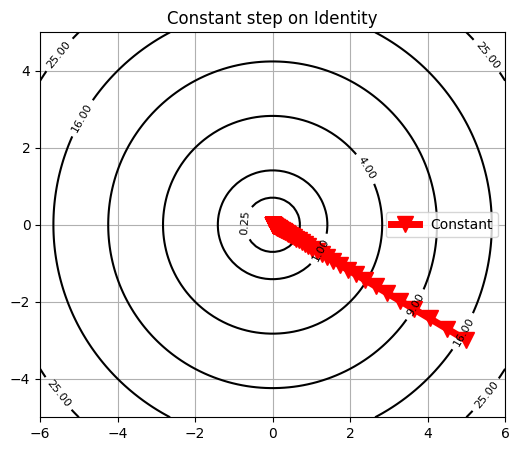

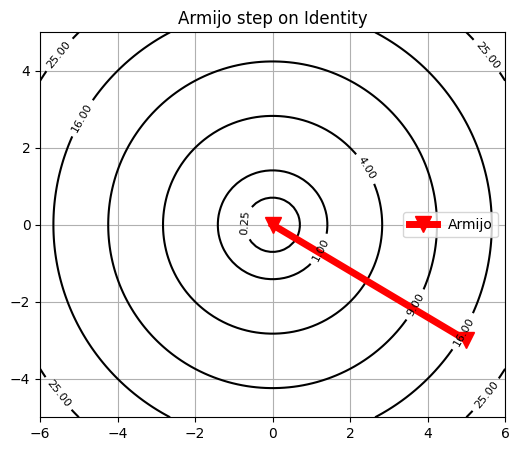

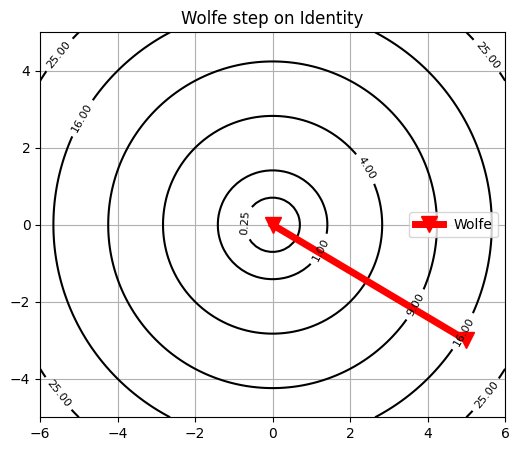

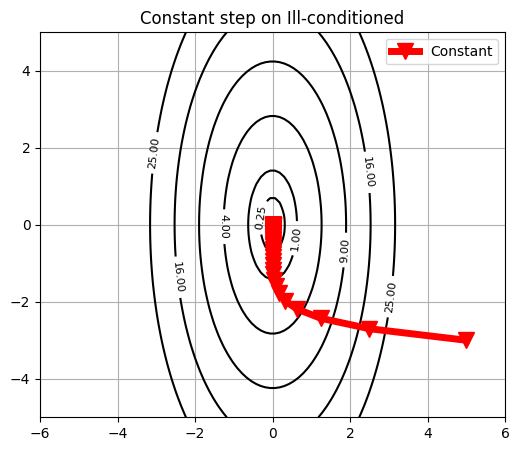

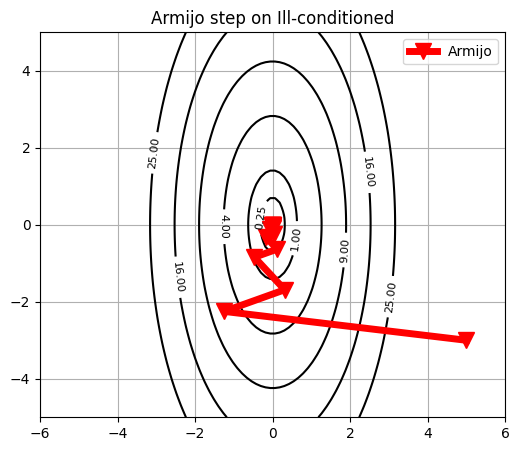

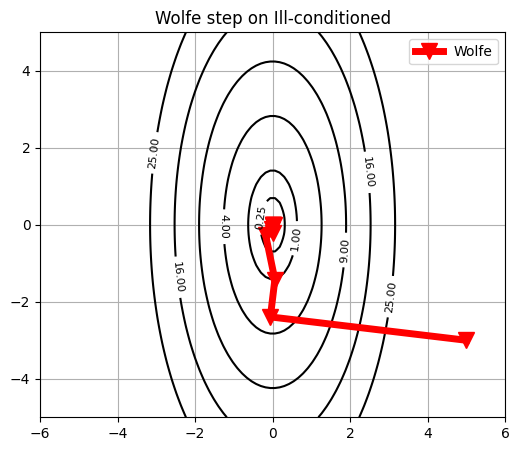

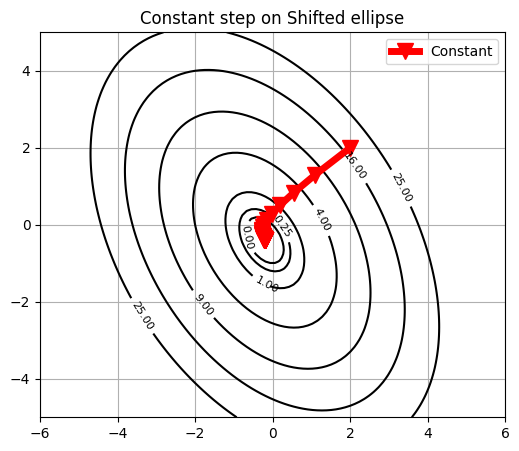

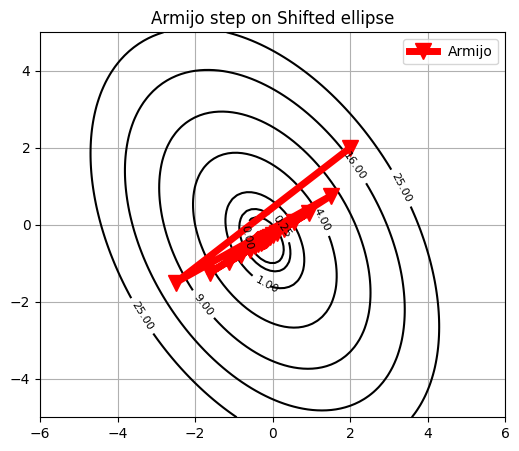

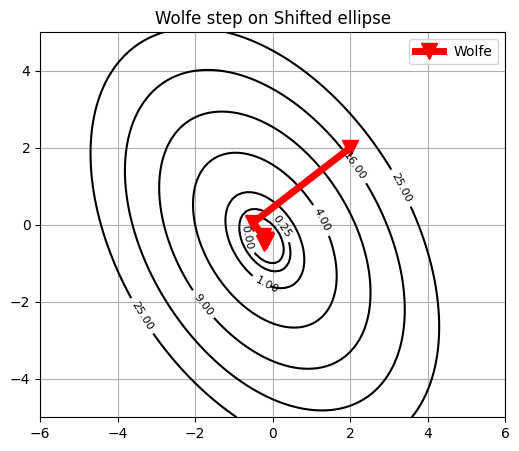

Функция: Identity, Метод: Constant
Сообщение метода: success
Найденный минимум: [ 0.00047023 -0.00028214]
Число итераций: 89

Функция: Identity, Метод: Armijo
Сообщение метода: success
Найденный минимум: [0. 0.]
Число итераций: 2

Функция: Identity, Метод: Wolfe
Сообщение метода: success
Найденный минимум: [0. 0.]
Число итераций: 2

Функция: Ill-conditioned, Метод: Constant
Сообщение метода: success
Найденный минимум: [ 1.69406589e-20 -2.32066203e-03]
Число итераций: 69

Функция: Ill-conditioned, Метод: Armijo
Сообщение метода: success
Найденный минимум: [ 0.00032589 -0.0017598 ]
Число итераций: 17

Функция: Ill-conditioned, Метод: Wolfe
Сообщение метода: success
Найденный минимум: [ 0.00013453 -0.00123002]
Число итераций: 11

Функция: Shifted ellipse, Метод: Constant
Сообщение метода: success
Найденный минимум: [-0.20042842 -0.3993068 ]
Число итераций: 48

Функция: Shifted ellipse, Метод: Armijo
Сообщение метода: success
Найденный минимум: [-0.19976238 -0.39985315]
Число итераций: 45


In [8]:
max_iter = 100
tolerance = 1e-8
constant_step = 0.1

experiments = [
    {'A': np.eye(2), 'b': np.zeros(2), 'x0': np.array([5.0, -3.0]), 'label': 'Identity'},
    {'A': np.array([[5, 0], [0, 1]]), 'b': np.zeros(2), 'x0': np.array([5.0, -3.0]), 'label': 'Ill-conditioned'},
    {'A': np.array([[3, 1], [1, 2]]), 'b': np.array([-1, -1]), 'x0': np.array([2.0, 2.0]), 'label': 'Shifted ellipse'}
]

line_search_methods = [
    {'method': 'Constant', 'params': {'start_with_one': False, 'c': constant_step}, 'label': 'Constant'},
    {'method': 'Armijo', 'params': {'c': 0.2, 'tau': 0.5}, 'label': 'Armijo'},
    {'method': 'Wolfe', 'params': {'c1': 0.1, 'c2': 0.9}, 'label': 'Wolfe'}
]

results = []

for exp in experiments:
    oracle = QuadraticOracle(exp['A'], exp['b'])

    for ls in line_search_methods:
        x_opt, message, history = gradient_descent(
            oracle=oracle,
            x_0=exp['x0'],
            tolerance=tolerance,
            max_iter=max_iter,
            line_search_options={'method': ls['method'], **ls['params']},
            trace=True,
            display=False
        )

        plt.figure(figsize=(6,5))
        plot_levels(oracle.func, levels=[0, 0.25, 1, 4, 9, 16, 25])
        plot_trajectory(oracle.func, history['x'], fit_axis=False, label=ls['label'])
        plt.title(f"{ls['label']} step on {exp['label']}")
        plt.legend()
        plt.show()

        results.append({
            'function': exp['label'],
            'method': ls['label'],
            'x_opt': x_opt,
            'message': message,
            'iterations': len(history['x'])
        })

for res in results:
    print(f"Функция: {res['function']}, Метод: {res['method']}")
    print(f"Сообщение метода: {res['message']}")
    print(f"Найденный минимум: {res['x_opt']}")
    print(f"Число итераций: {res['iterations']}\n")


# Эксперимент 2: Зависимость числа итераций градиентного спуска от числа обусловленности и размерности пространства

Исследуйте, как зависит число итераций, необходимое градиентному спуску для сходимости, от следующих двух параметров:
1) числа обусловленности $k \geq 1$ оптимизируемой функции и
2) размерности пространства $n$ оптимизируемых переменных.

Для этого для заданных параметров $n$ и $k$ сгенерируйте случайным образом квадратичную задачу размера $n$ с числом обусловленности $k$ и запустите на ней градиентный спуск с некоторой фиксированной требуемой точностью. Замерьте число итераций $T(n,k)$, которое потребовалось сделать методу до сходимости (успешному выходу по критерию остановки).

**Рекомендация:** Проще всего сгенерировать случайную квадратичную задачу размера $n$ с заданным числом обусловленности $k$ следующим образом. В качестве матрицы $A \in S_{n}^{++}$ удобно взять просто диагональную матрицу $A = \text{Diag}(a)$, у которой диагональные элементы сгенерированы случайно в пределах $[1,k]$, причем $\min(a) = 1$, $\max(a) = k$. В качестве вектора $b \in \mathbb{R}^n$ можно взять вектор со случайными элементами. Диагональные матрицы удобно рассматривать, поскольку с ними можно эффективно работать даже при больших значениях $n$. Рекомендуется хранить матрицу $A$ в формате разреженной диагональной матрицы (см. $\texttt{scipy.sparse.diags}$).

Зафиксируйте некоторое значение размерности $n$. Переберите различные числа обусловленности $k$ по сетке и построите график зависимости $T(k,n)$ от $k$. Поскольку каждый раз квадратичная задача генерируется случайным образом, то повторите этот эксперимент несколько раз. В результате для фиксированного значения $n$ у Вас должно получиться целое семейство кривых зависимости $T(k,n)$ от $k$. Нарисуйте все эти кривые одним и тем же цветом для наглядности (например, красным).

Теперь увеличьте значение $n$ и повторите эксперимент снова. Вы должны получить новое семейство кривых $T(n',k)$ против $k$. Нарисуйте их все одним и тем же цветом, но отличным от предыдущего (например, синим).


Повторите эту процедуру несколько раз для других значений $n$. В итоге должно получиться несколько разных семейств кривых - часть красных (соответствующих одному значению $n$), часть синих (соответствующих другому значению $n$), часть зеленых и т. д.

Обратите внимание, что значения размерности $n$ имеет смысл перебирать по логарифмической сетке (например, $n = 10$, $n = 100$, $n = 1000$ и т. д.).

Какие выводы можно сделать из полученной картинки?



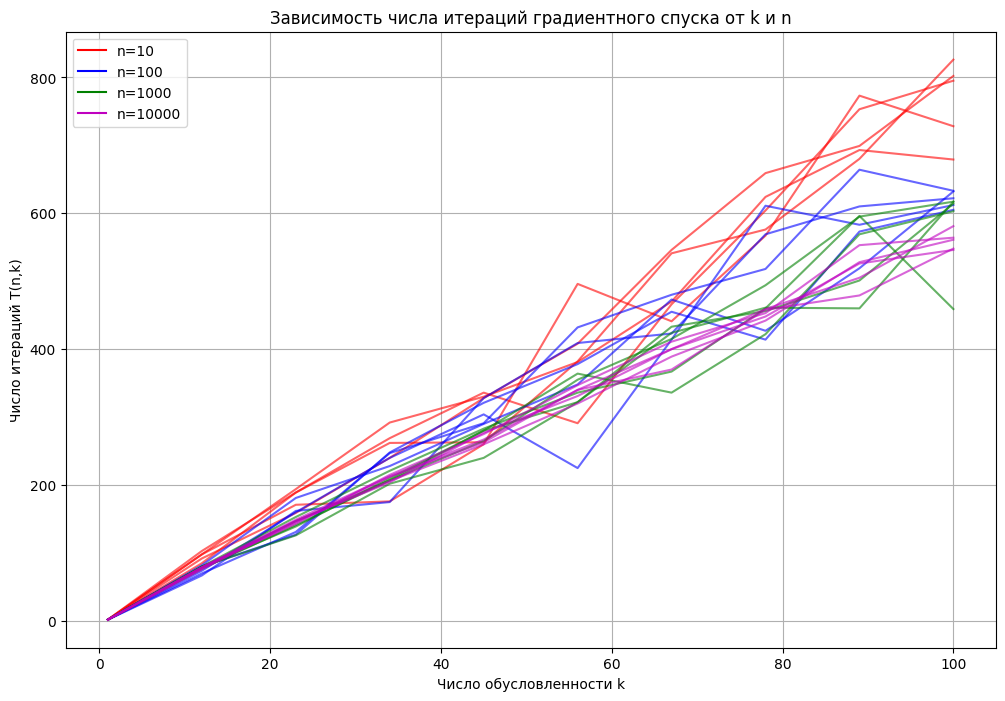

In [9]:
def generate_quadratic_problem(n, k):
    diag = np.random.uniform(1, k, size=n)
    diag[0] = 1
    diag[-1] = k
    A = scipy.sparse.diags(diag).toarray()
    b = np.random.randn(n)
    return A, b

n_values = [10, 100, 1000, 10000]
k_values = np.linspace(1, 100, 10)
repeats = 5
colors = ['r', 'b', 'g', 'm']
plt.figure(figsize=(12,8))

for idx, n in enumerate(n_values):
    for rep in range(repeats):
        T_list = []
        for k in k_values:
            A, b = generate_quadratic_problem(n, k)
            oracle = QuadraticOracle(A, b)
            L = np.max(np.diag(A))
            alpha = 1.0 / L
            x0 = np.zeros(n)


            x_opt, message, history = gradient_descent(
                oracle=oracle,
                x_0=x0,
                tolerance=tolerance,
                max_iter=1000000,
                line_search_options={'method': 'Constant', 'c': alpha},
                trace=True,
                display=False
            )

            T_list.append(len(history['func']))

        plt.plot(k_values, T_list, color=colors[idx], alpha=0.6)

plt.xlabel("Число обусловленности k")
plt.ylabel("Число итераций T(n,k)")
plt.title("Зависимость числа итераций градиентного спуска от k и n")
plt.grid(True)

for idx, n in enumerate(n_values):
    plt.plot([], [], color=colors[idx], label=f"n={n}")
plt.legend()

plt.show()

# Задача 1: Обоснование константного шага для градиентного спуска

Рассмотрим квадратичную функцию $f(x) = \frac{1}{2}\langle Ax, x\rangle - \langle b, x\rangle$, где $A \in \mathbb{S}_{++}^n$,

Пусть
$
A = \begin{pmatrix}
5 & 1 \\
1 & 3
\end{pmatrix}, \quad
b = \begin{pmatrix}
1 \\ 2
\end{pmatrix}, \quad
x_0 = \begin{pmatrix}
0 \\ 0
\end{pmatrix}
$

Предъявите конкретное значение константного шага $\alpha$, гарантирующее сходимость градиентного спуска для данной функции, и строго обоснуйте свой выбор.


Градиент $L$-липшицевый, как следствие по теореме $\alpha = \frac{1}{L}$.  
$\nabla f(x) = Ax - b$  
$||\nabla f(y) - \nabla f(x)|| \leq ||A|| \cdot ||y - x||$  
Равенство только при собственном векторе, у которого собственное число максимально по модулю. То есть  
$\det(A-\lambda I)=0 ⇔ (5-\lambda)(3-\lambda)-1=0$  
Тогда  
$\lambda=4 \pm \sqrt{2} \implies ||A|| = 4 + \sqrt{2}$  
$\alpha = \frac{1}{4 + \sqrt{2}}$

# Эксперимент 3: Стратегия выбора длины шага в градиентном спуске

Исследовать, как зависит поведение метода от стратегии подбора шага: константный шаг (попробовать различные значения), бэктрэкинг (попробовать различные константы $c$), условия Вульфа (попробовать различные параметры $c_2$), метод Брента и метод золотого сечения.

Рассмотрите квадратичную функцию и логистическую регрессию с модельными данными (сгенерированными случайно). (Следует рассматривать матрицы размерностью m, n = 10000, 8000, можно также рассмотреть и другие варианты)

Запустите для этих функций градиентный спуск с разными стратегиями выбора шага из одной и той же начальной точки.

Нарисуйте кривые сходимости (относительная невязка по функции в логарифмической шкале против числа итераций — для квадратичной функции, относительный квадрат нормы градиента в логарифмической шкале против числа итераций — для логистической регрессии) для разных стратегий на одном графике.

Попробуйте разные начальные точки. Ответьте на вопрос: Какая стратегия выбора шага является самой лучшей?



Const 0.01: iterations_exceeded
Const 0.001: iterations_exceeded
Armijo 1e-4: success
Armijo 1e-1: success
Wolfe 1e-4 0.5: success
Wolfe 1e-3 0.8: success
Wolfe 1e-4 0.9: success
Brent: success
Golden: success


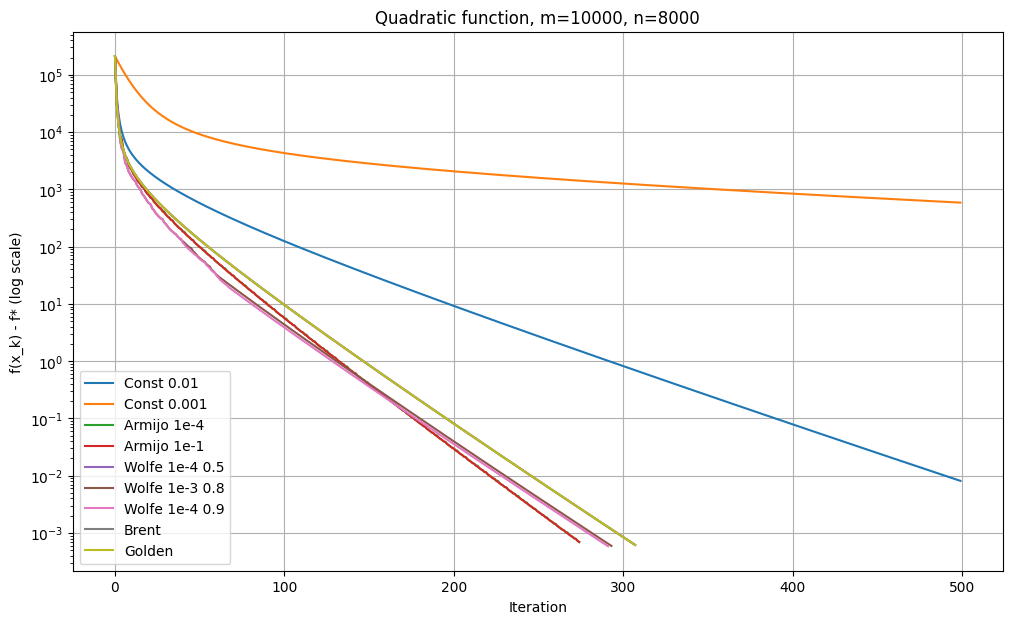

In [16]:
m, n = 10000, 8000
np.random.seed(3)

A = scipy.sparse.diags(np.random.uniform(1, 100, size=n)).toarray()
b = np.random.uniform(-15, 15, size=n)
quad_oracle = QuadraticOracle(A, b)

x0_1 = np.random.randn(n)
x0_2 = np.random.randn(n)

tools = [
    ("Const 0.01", {"method": "Constant", "c": 0.01}),
    ("Const 0.001", {"method": "Constant", "c": 0.001}),
    ("Armijo 1e-4", {"method": "Armijo", "c1": 1e-4}),
    ("Armijo 1e-1", {"method": "Armijo", "c1": 1e-1}),
    ("Wolfe 1e-4 0.5", {"method": "Wolfe", "c1": 1e-4, "c2": 0.5}),
    ("Wolfe 1e-3 0.8", {"method": "Wolfe", "c1": 1e-3, "c2": 0.8}),
    ("Wolfe 1e-4 0.9", {"method": "Wolfe", "c1": 1e-4, "c2": 0.9}),
    ("Brent", {"method": "Brent"}),
    ("Golden", {"method": "Golden"})
]

max_iter = 500
tolerance = 1e-10

f_opt = quad_oracle.func(np.linalg.solve(A, b))

plt.figure(figsize=(12,7))

for name, opts in tools:
    x_opt, msg, history = gradient_descent(
        quad_oracle, x0_1,
        max_iter=max_iter,
        tolerance=tolerance,
        line_search_options=opts,
        trace=True,
        display=False
    )
    print(f"{name}: {msg}")

    f_vals = np.array(history["func"])
    rel_res = np.maximum(f_vals - f_opt, 1e-16)
    plt.semilogy(rel_res, label=name)

plt.xlabel("Iteration")
plt.ylabel("f(x_k) - f* (log scale)")
plt.title(f"Quadratic function, m={m}, n={n}")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipython-input-3590726365.py:112: LineSearchWarning: The line search algorithm did not converge
  res = scipy.optimize.line_search(f_vec, g_vec, x_k, d_k, gfk=gfk,


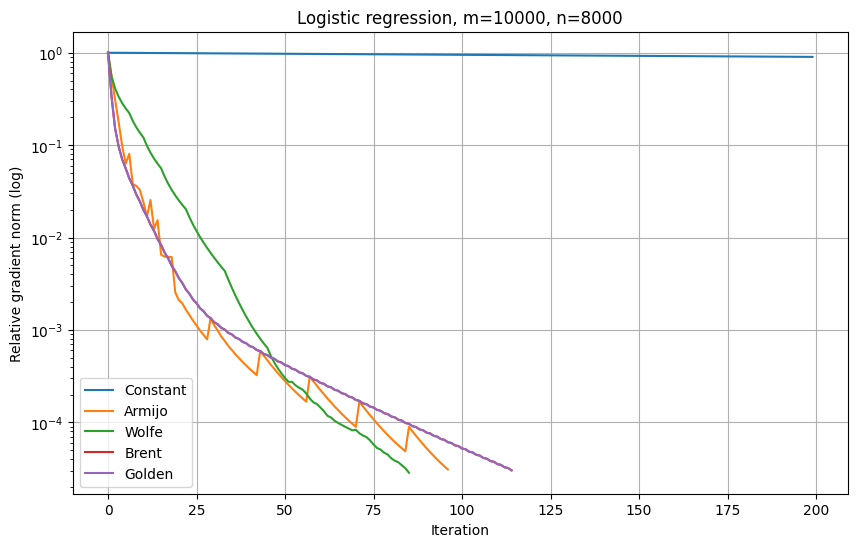

In [17]:

m, n = 10000, 8000

A = np.random.randn(m, n)
true_x = np.random.randn(n)
b = np.sign(A @ true_x + 0.1 * np.random.randn(m))

reg = 1e-3
oracle = create_log_reg_oracle(A, b, reg)
x0 = np.zeros(n)

methods = [
    ('Constant', {'method': 'Constant', 'c': 1e-3}),
    ('Armijo',   {'method': 'Armijo', 'c1': 0.2}),
    ('Wolfe',    {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9}),
    ('Brent',    {'method': 'Brent'}),
    ('Golden',   {'method': 'Golden'})
]

plt.figure(figsize=(10,6))

for name, opts in methods:
    x_opt, msg, hist = gradient_descent(
        oracle, x0,
        tolerance=1e-9,
        max_iter=200,
        line_search_options=opts,
        trace=True
    )

    grad_norms = np.array(hist["grad_norm"])
    rel_grad = grad_norms / grad_norms[0]

    plt.semilogy(rel_grad, label=name)

plt.xlabel("Iteration")
plt.ylabel("Relative gradient norm (log)")
plt.title(f"Logistic regression, m={m}, n={n}")
plt.grid(True)
plt.legend()
plt.show()

Лучшей стратегией является Wolfe

# Метод Нютона

Реализовать метод Ньютона (функция newton).

$$
x_{k+1} = x_k - \alpha_k \left[ \nabla^2 f(x_k) \right]^{-1} \nabla f(x_k)
$$

Для метода Ньютона очень важно использовать единичный шаг $\alpha_k = 1$, чтобы обеспечить локальную квадратичную сходимость. Поэтому в алгоритмах линейного поиска нужно всегда первым делом пробовать единичный шаг. Теория гарантирует, что в зоне квадратичной сходимости метода Ньютона единичный шаг будет удовлетворять условиям Армихо/Вульфа, и поэтому автоматически будет приниматься. Если единичный шаг не удовлетворяет условиям Армихо/Вульфа, то алгоритмы линейного поиска его уменьшат и, тем самым, обеспечат глобальную сходимость метода Ньютона.

Вычисление Ньютоновского направления $d_k = -\left[ \nabla^2 f(x_k) \right]^{-1} \nabla f(x_k)$ эквивалентно решению линейной системы уравнений:

$$\nabla^2 f(x_k) d_k = -\nabla f(x_k)$$

Если гессиан - положительно определённая матрица: $\nabla^2 f(x_k) \succ 0$, то предпочтительным методом решения такой системы является **разложение Холецкого**, которое также, как и метод Гаусса, работает за $O(n^3)$, но является вычислительно более эффективным. Если матрица системы не является положительно определённой, то метод Холецкого сможет обнаружить и сообщить об этом.

**Замечание:** Для поиска направления в методе Ньютона не нужно в явном виде обращать гессиан (с помощью функции np.linalg.inv) или использовать самый общий метод для решения системы линейных уравнений (numpy.linalg.solve). Вместо этого следует учесть тот факт, что в рассматриваемой задаче гессиан является симметричной положительно определенной матрицей и воспользоваться разложением Холецкого (функции scipy.linalg.cho_factor и scipy.linalg.cho_solve).

In [18]:
def newton(oracle, x_0, tolerance=1e-5, max_iter=100,
           line_search_options=None, trace=False, display=False):
    """
    Newton's method using Cholesky factorization for positive-definite Hessians.
    Tries alpha=1 first in line search for quadratic convergence.
    """

    history = defaultdict(list) if trace else None
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)
    start = datetime.now()

    g0 = oracle.grad(x_k)
    g0_norm2 = float(np.dot(g0, g0))

    for it in range(max_iter):
        g_k = oracle.grad(x_k)
        gk_norm2 = float(np.dot(g_k, g_k))

        if trace:
            dt = (datetime.now() - start).total_seconds()
            history["time"].append(dt)
            history["func"].append(oracle.func(x_k))
            history["grad_norm"].append(np.sqrt(gk_norm2))
            if x_k.size <= 2:
                history["x"].append(np.copy(x_k))

        if gk_norm2 <= tolerance * g0_norm2:
            return x_k, "success", history

        H = oracle.hess(x_k)
        try:
            c, lower = scipy.linalg.cho_factor(H)
            d_k = scipy.linalg.cho_solve((c, lower), -g_k)
        except np.linalg.LinAlgError:
            return x_k, "newton_direction_error", history

        alpha0 = 1.0
        if line_search_options is not None:
            alpha = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha=alpha0)
        else:
            alpha = 1.0

        if alpha is None or np.isnan(alpha) or np.isinf(alpha):
            return x_k, "computational_error", history

        x_k = x_k + alpha * d_k

        if display:
            print(f"it={it}, f={oracle.func(x_k):.6e}, "
                  f"||g||={np.sqrt(gk_norm2):.3e}, alpha={alpha:.3e}")

    return x_k, "iterations_exceeded", history

# Эксперимент 4: Сравнение методов градиентного спуска и Ньютона на реальной задаче логистической регрессии

Сравнить методы градиентного спуска и Ньютона на задаче обучения логистической регрессии на реальных данных. В качестве реальных данных используйте следующие три набора с сайта LIBSVM [3]: $\texttt{w8a}$, $\texttt{gisette}$ и $\texttt{real-sim}$. https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/

Коэффициент регуляризации взять стандартным образом: $\lambda = \frac{1}{m}$.

Параметры обоих методов взять равными параметрам по умолчанию.

Начальную точку выбрать $x_0 = 0$.

Построить графики сходимости следующих двух видов:

(a) Зависимость значения функции от реального времени работы метода.

(b) Зависимость относительного квадрата нормы градиента $\frac{\|\nabla f(x_k)\|^2}{\|\nabla f(x_0)\|^2}$ (в логарифмической шкале) против реального времени работы.

При этом оба метода (градиентный спуск и Ньютон) нужно рисовать на одном и том же графике.

Укажите в отчете, какова стоимость итерации и сколько памяти требуется каждому из методов в зависимости от параметров $m$ (размер выборки) и $n$ (размерность пространства). При оценке используйте нотацию $O(\cdot)$, скрывающую внутри себя абсолютные константы.

Какие выводы можно сделать по результатам этого эксперимента? Какой из методов лучше и в каких ситуациях?

*Рекомендация:* Любой набор данных с сайта LIBSVM представляет из себя текстовый файл в формате svmlight. Чтобы считать такой текстовый файл, можно использовать функцию $\texttt{load_svmlight_file}$ из модуля $\texttt{sklearn.datasets}$. Обратите внимание, что эта функция возвращает матрицу в формате $\texttt{scipy.sparse.csr_matrix}$, поэтому Ваша реализация логистического оракула должна поддерживать такие матрицы.

\

--- Dataset: w8a ---


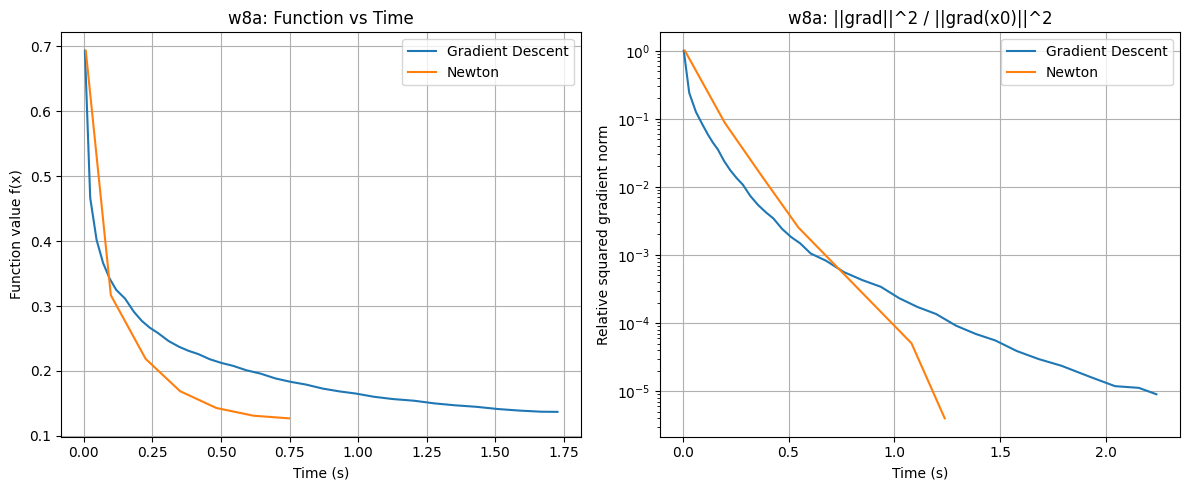

m = 49749, n = 300
Gradient Descent: Cost per iteration O(m*n), memory O(n + nnz(X))
Newton: Cost per iteration O(m*n^2 + n^3), memory O(n^2 + nnz(X))


Extracting gisette_scale.bz2...
--- Dataset: gisette ---


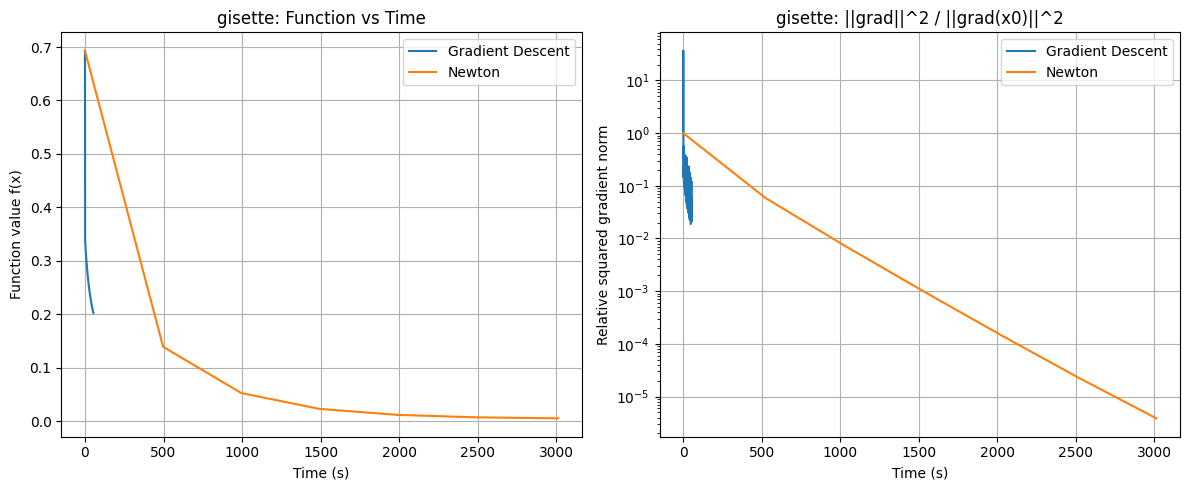

m = 6000, n = 5000
Gradient Descent: Cost per iteration O(m*n), memory O(n + nnz(X))
Newton: Cost per iteration O(m*n^2 + n^3), memory O(n^2 + nnz(X))




HTTPError: HTTP Error 404: Not Found

In [26]:
import os
import bz2
import urllib.request
from sklearn.datasets import load_svmlight_file
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

def download_file(url, filename):
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)

def extract_bz2(filename):
    if filename.endswith(".bz2"):
        extracted_name = filename[:-4]
        if not os.path.exists(extracted_name):
            with bz2.open(filename, 'rb') as f_in, open(extracted_name, 'wb') as f_out:
                f_out.write(f_in.read())
        return extracted_name
    return filename

datasets = [
    ("w8a", "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a"),
    ("gisette", "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/gisette_scale.bz2"),
    ("real-sim", "https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/real-sim")
]

x0_seed = 42
tolerance = 1e-5
max_iter = 100

methods = [
    ("Gradient Descent", gradient_descent),
    ("Newton", newton)
]

for name, url in datasets:
    file_name = url.split('/')[-1]
    download_file(url, file_name)
    file_path = extract_bz2(file_name)

    print(f"--- Dataset: {name} ---")
    X, y = load_svmlight_file(file_path)
    X = X.tocsr()
    m, n = X.shape
    reg_coef = 1.0 / m

    oracle = create_log_reg_oracle(X, y, reg_coef)

    np.random.seed(x0_seed)
    x0 = np.zeros(n)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    for method_name, method in methods:
        x_opt, msg, history = method(
            oracle,
            x0,
            tolerance=tolerance,
            max_iter=max_iter,
            trace=True,
            display=False
        )
        times = np.array(history['time'])
        f_vals = np.array(history['func'])
        plt.plot(times, f_vals, label=method_name)
    plt.xlabel("Time (s)")
    plt.ylabel("Function value f(x)")
    plt.title(f"{name}: Function vs Time")
    plt.grid(True)
    plt.legend()

    plt.subplot(1,2,2)
    for method_name, method in methods:
        x_opt, msg, history = method(
            oracle,
            x0,
            tolerance=tolerance,
            max_iter=max_iter,
            trace=True,
            display=False
        )
        times = np.array(history['time'])
        grad_norm = np.array(history['grad_norm'])
        grad_rel = (grad_norm**2) / (grad_norm[0]**2 + 1e-16)
        plt.semilogy(times, grad_rel, label=method_name)
    plt.xlabel("Time (s)")
    plt.ylabel("Relative squared gradient norm")
    plt.title(f"{name}: ||grad||^2 / ||grad(x0)||^2")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"m = {m}, n = {n}")
    print("Gradient Descent: Cost per iteration O(m*n), memory O(n + nnz(X))")
    print("Newton: Cost per iteration O(m*n^2 + n^3), memory O(n^2 + nnz(X))")
    print("\n")

Градиентный спуск: время O(mn), память O(mn)  
Ньютон: время O(mn^2 + n^3), память O(n^2 + mn)

В случае плотных матриц, иначе асимптотики чуть лучше ввиду уменьшения m

Ньютон лучше на меньших данных (w8a), в то время как для более масштабных лучше себя показал градиентный спуск



# Эксперимент 5: Стратегия выбора длины шага в методе Ньютона



Повторите эксперимент 3 со сравнением стратегий выбора шага на логистической регрессии с модельной выборкой, но для метода Ньютона. Какая стратегия работает лучше всего?



`Ваш ответ здесь`